# CPE 342 Machine Learning — Assignment 2: Training Models
**Author:** 67070501042 วิศิษฐ์ สุวรรณเนาว์

## 1. Problem Overview
In this assignment, we use an **iterative approach** (Gradient Descent) to train a model and fit it to a dataset of 100 observations ($n=100$). 

The goal is to fit a quadratic model without a linear $x$ term:
$$ \hat{y} = C_0 + C_1 x^2 $$
Where:
- $C_0$ is the y-intercept (Bias)
- $C_1$ is the coefficient of $x^2$ (Slope of $x^2$)

## 2. Library & Font Setup
Loading libraries and downloading the Sarabun font to support Thai rendering in Matplotlib if needed.

In [1]:
# Download TH Sarabun New font for Matplotlib
!wget -q https://github.com/Phonbopit/sarabun-webfont/raw/master/fonts/thsarabunnew-webfont.ttf

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm
import urllib.request
import os

# Font configuration
font_path = 'thsarabunnew-webfont.ttf'
if not os.path.exists(font_path):
    urllib.request.urlretrieve('https://github.com/Phonbopit/sarabun-webfont/raw/master/fonts/thsarabunnew-webfont.ttf', font_path)
fm.fontManager.addfont(font_path)
mpl.rc('font', family='TH Sarabun New', size=14)
mpl.rcParams['axes.unicode_minus'] = False # Prevent minus sign rendering issues

print("Library and font setup complete")

'wget' is not recognized as an internal or external command,
operable program or batch file.


Library and font setup complete


## 3. Data Loading & Exploratory Data Analysis (EDA)
Read the data from the CSV file and plot scatter plots to observe the relationship between $x$ and $y$.

,X,Y
0,4.072280,0.981321
1,1.724332,1.124653
2,1.901981,1.042435
3,4.914068,0.949332
4,1.165868,1.186925


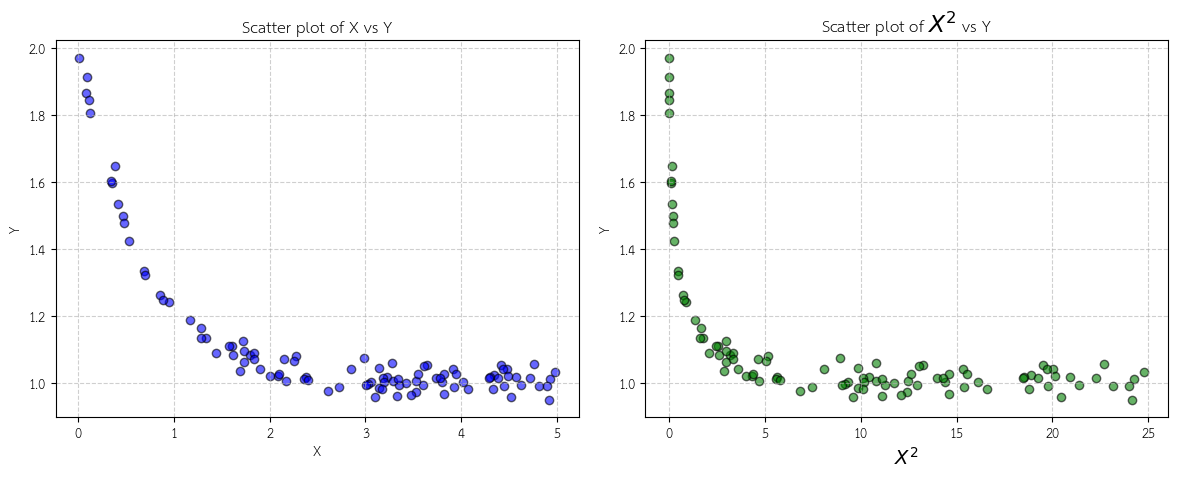

In [2]:
# Read data
df = pd.read_csv('CPE342_Assignment 2_Data.csv')
X = df['X'].values
Y = df['Y'].values

# Display first few rows
display(df.head())

# Plot graphs to observe trends
plt.figure(figsize=(12, 5))

# Plot X vs Y
plt.subplot(1, 2, 1)
plt.scatter(X, Y, color='blue', alpha=0.6, edgecolor='k')
plt.title('Scatter plot of X vs Y')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True, linestyle='--', alpha=0.6)

# Plot X^2 vs Y
plt.subplot(1, 2, 2)
plt.scatter(X**2, Y, color='green', alpha=0.6, edgecolor='k')
plt.title('Scatter plot of $X^2$ vs Y')
plt.xlabel('$X^2$')
plt.ylabel('Y')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## Task 1 — Loss Function
Given our model $\hat{y}_i = C_0 + C_1 x_i^2$, 

The loss function we use is the **Mean Squared Error (MSE)**, which computes the average squared differences (residuals) across all data points:

$$ L(C_0, C_1) = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 $$

Substituting $\hat{y}_i$ gives our target equation:
$$ L(C_0, C_1) = \frac{1}{n} \sum_{i=1}^{n} (y_i - C_0 - C_1 x_i^2)^2 $$

## Task 2 — Gradient of Each Coefficient
To compute the gradients of the loss function $L$ with respect to each parameter ($C_0$ and $C_1$), we apply the **chain rule**. 

For any coefficient $\theta$, the partial derivative is:
$$ \frac{\partial L}{\partial \theta} = \frac{\partial}{\partial \theta} \left[ \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 \right] $$
$$ = \frac{1}{n} \sum_{i=1}^{n} 2(y_i - \hat{y}_i) \cdot \frac{\partial}{\partial \theta}(y_i - \hat{y}_i) $$
$$ = -\frac{2}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i) \cdot \frac{\partial \hat{y}_i}{\partial \theta} $$

---
### 1. Gradient with respect to $C_0$:
First, find $\frac{\partial \hat{y}_i}{\partial C_0}$:
$$ \hat{y}_i = C_0 + C_1 x_i^2 $$
$$ \frac{\partial \hat{y}_i}{\partial C_0} = \frac{\partial}{\partial C_0}(C_0 + C_1 x_i^2) = 1 + 0 = 1 $$

Substituting this back into the chain rule formula:
$$ \frac{\partial L}{\partial C_0} = -\frac{2}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i) \cdot 1 $$
$$ \frac{\partial L}{\partial C_0} = -\frac{2}{n} \sum_{i=1}^{n} (y_i - C_0 - C_1 x_i^2) $$

---
### 2. Gradient with respect to $C_1$:
First, find $\frac{\partial \hat{y}_i}{\partial C_1}$:
$$ \hat{y}_i = C_0 + C_1 x_i^2 $$
$$ \frac{\partial \hat{y}_i}{\partial C_1} = \frac{\partial}{\partial C_1}(C_0 + C_1 x_i^2) = 0 + x_i^2 = x_i^2 $$

Substituting this back into the chain rule formula:
$$ \frac{\partial L}{\partial C_1} = -\frac{2}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i) \cdot x_i^2 $$
$$ \frac{\partial L}{\partial C_1} = -\frac{2}{n} \sum_{i=1}^{n} (y_i - C_0 - C_1 x_i^2) x_i^2 $$

## Task 3 — Update Rules
In each iteration $t$, the parameters are updated in the opposite direction of the gradient to minimize the loss, scaled by the learning rate $\eta$:

$$ C_0^{(t+1)} = C_0^{(t)} - \eta \cdot \frac{\partial L}{\partial C_0} $$
$$ C_1^{(t+1)} = C_1^{(t)} - \eta \cdot \frac{\partial L}{\partial C_1} $$

## Task 4 — Gradient Descent Implementation
In this section, we implement the code to find $C_0$ and $C_1$ using basic NumPy, based on the mathematical equations derived in the previous tasks.

In [3]:
# Hyperparameters
learning_rate = 0.01  
n_iterations = 5000   
n = len(Y)            

# Initialize parameters
C0 = 0.0
C1 = 0.0

# Prepare lists to store history (for visualization later)
history_loss = []
history_C0 = []
history_C1 = []

# Pre-compute X^2 to reduce computation inside the loop
X_sq = X**2

# Gradient Descent Loop
for i in range(n_iterations):
    # 1. Calculate Predictions
    Y_pred = C0 + C1 * X_sq
    
    # 2. Calculate Errors/Residuals
    error = Y - Y_pred
    
    # 3. Calculate Loss (MSE)
    loss = np.mean(error**2)
    history_loss.append(loss)
    history_C0.append(C0)
    history_C1.append(C1)
    
    # 4. Calculate Gradients
    grad_C0 = -(2/n) * np.sum(error)
    grad_C1 = -(2/n) * np.sum(error * X_sq)
    
    # 5. Update Parameters
    C0 = C0 - learning_rate * grad_C0
    C1 = C1 - learning_rate * grad_C1
    
    # Print progress every 500 iterations
    if i % 500 == 0 or i == n_iterations - 1:
        print(f"Iteration {i:4d} | Loss: {loss:.5f} | C0: {C0:.5f} | C1: {C1:.5f}")

print("-" * 50)
print(f"Training complete over {n_iterations} iterations")
print(f"Optimized Parameters: C0 = {C0:.4f}, C1 = {C1:.4f}")
print(f"Final MSE Loss: {history_loss[-1]:.6f}")

Iteration    0 | Loss: 1.30516 | C0: 0.02239 | C1: 0.19326
Iteration  500 | Loss: 29069515684937664925228118163858805566530781889434005389433403805222377910317715308313117129120324930174119955039112298010164831149862982202574535712366292684989657242451144160389728144285209446153301234975757141990641264993607681237385306873386519298632152156191714045107101038237066461184.00000 | C0: 56156804007491268487386728259232487380347653114795076436905794845138559884689198368328822635176811808909294381396874032201625573998152696987648.00000 | C1: 863352064492172644607827101890291995626742858837225777707831344187337877221097169612817125560813326919518753668519248370542239994475102406180864.00000
Iteration 1000 | Loss: inf | C0: 37838395030188472687685407826155145602216638473684468718571038526521074786743294060380891317780567034973141224710682141576631265077061149145702263235273780081617859428561018146741852422537952467425700887699532883648148842635881913986177122144186004829338363251393246456028765

C:\Users\Admin\AppData\Roaming\Python\Python312\site-packages\numpy\_core\_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
C:\Users\Admin\AppData\Local\Temp\ipykernel_2560\3501735774.py:27: RuntimeWarning: overflow encountered in square
  loss = np.mean(error**2)
C:\Users\Admin\AppData\Roaming\Python\Python312\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\Admin\AppData\Local\Temp\ipykernel_2560\3501735774.py:38: RuntimeWarning: invalid value encountered in scalar subtract
  C1 = C1 - learning_rate * grad_C1


## Task 5 — Results & Visualizations
In this section, we analyze the behavior of our trained model and evaluate how well it fits the dataset using various plots.

<>:25: SyntaxWarning: invalid escape sequence '\h'
<>:38: SyntaxWarning: invalid escape sequence '\h'
<>:25: SyntaxWarning: invalid escape sequence '\h'
<>:38: SyntaxWarning: invalid escape sequence '\h'
C:\Users\Admin\AppData\Local\Temp\ipykernel_2560\1276841915.py:25: SyntaxWarning: invalid escape sequence '\h'
  ax3.plot(x_line, y_line, 'r-', linewidth=3, label=f'Fitted Model: $\hat{{y}} = {C0:.4f} + {C1:.4f}x^2$')
C:\Users\Admin\AppData\Local\Temp\ipykernel_2560\1276841915.py:38: SyntaxWarning: invalid escape sequence '\h'
  ax4.set_ylabel('Residuals ($y_i - \hat{y}_i$)')
C:\Users\Admin\AppData\Roaming\Python\Python312\site-packages\matplotlib\scale.py:270: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


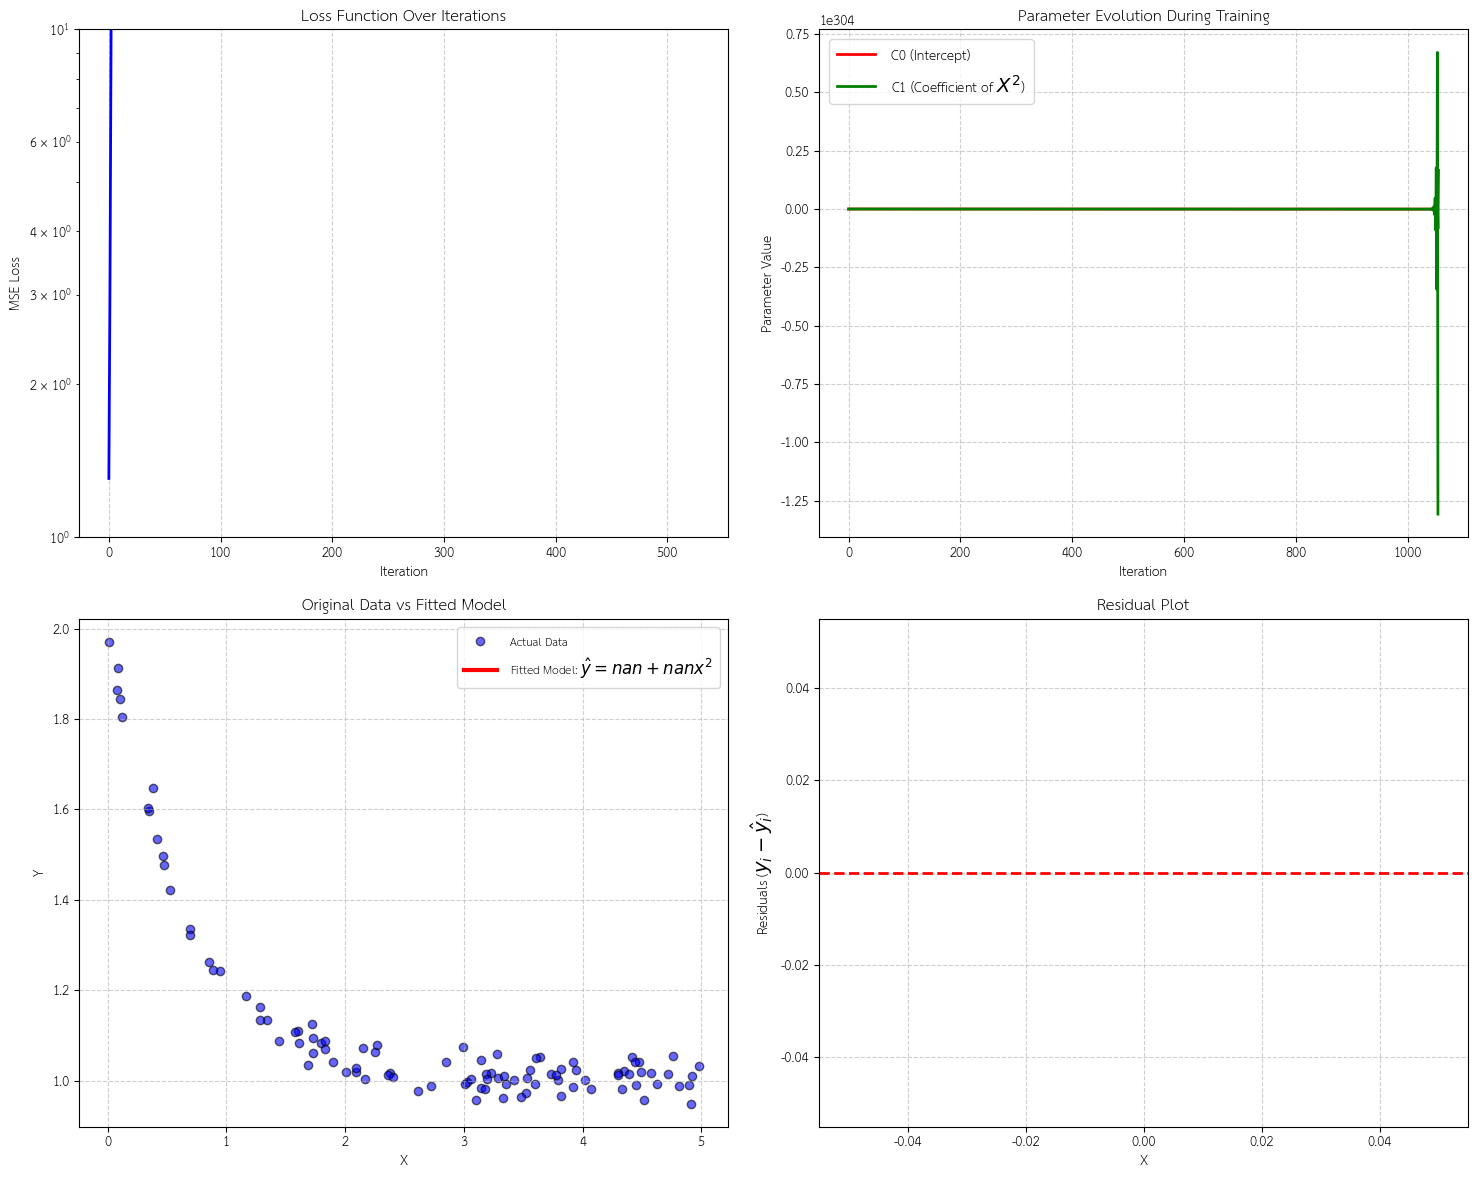

In [4]:
# Create subplots for a 2x2 grid visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Learning Curve (Loss over Iterations)
ax1.plot(range(n_iterations), history_loss, 'b-', linewidth=2)
ax1.set_xlabel('Iteration')
ax1.set_ylabel('MSE Loss')
ax1.set_title('Loss Function Over Iterations')
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.set_yscale('log') # Log scale to see convergence better

# Plot 2: Convergence of parameters C0 and C1
ax2.plot(range(n_iterations), history_C0, 'r-', label='C0 (Intercept)', linewidth=2)
ax2.plot(range(n_iterations), history_C1, 'g-', label='C1 (Coefficient of $X^2$)', linewidth=2)
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Parameter Value')
ax2.set_title('Parameter Evolution During Training')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

# Plot 3: Fitted Curve vs Actual Data
x_line = np.linspace(min(X), max(X), 100)
y_line = C0 + C1 * (x_line**2)
ax3.scatter(X, Y, color='blue', alpha=0.6, label='Actual Data', edgecolor='k')
ax3.plot(x_line, y_line, 'r-', linewidth=3, label=f'Fitted Model: $\hat{{y}} = {C0:.4f} + {C1:.4f}x^2$')
ax3.set_xlabel('X')
ax3.set_ylabel('Y')
ax3.set_title('Original Data vs Fitted Model')
ax3.legend(fontsize=12)
ax3.grid(True, linestyle='--', alpha=0.6)

# Plot 4: Residuals
Y_pred_final = C0 + C1 * X_sq
residuals = Y - Y_pred_final
ax4.scatter(X, residuals, color='purple', alpha=0.6, edgecolor='k')
ax4.axhline(0, color='red', linestyle='--', linewidth=2)
ax4.set_xlabel('X')
ax4.set_ylabel('Residuals ($y_i - \hat{y}_i$)')
ax4.set_title('Residual Plot')
ax4.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## Task 6 — Model Evaluation (R-squared & Summary Statistics)
To mathematically evaluate the goodness of fit for our machine learning model, we calculate the Coefficient of Determination, also known as $R^2$.

The formula for $R^2$ is:
$$ R^2 = 1 - \frac{SS_{res}}{SS_{tot}} $$

Where:
- **Residual Sum of Squares ($SS_{res}$)** is the sum of the squared differences between the actual and predicted values:
$$ SS_{res} = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 $$
- **Total Sum of Squares ($SS_{tot}$)** is the sum of the squared differences between the actual values and the mean of the actual values ($\bar{y}$):
$$ SS_{tot} = \sum_{i=1}^{n} (y_i - \bar{y})^2 $$

A higher $R^2$ score (closer to 1) indicates that our model's predictions closely match the actual data points.

In [5]:
# Print summary statistics
print("\n=== MODEL EVALUATION SUMMARY ===")
print(f"Fitted parameters: C0 = {C0:.6f}, C1 = {C1:.6f}")
print(f"Total Iterations: {len(history_loss)}")
print(f"Initial loss: {history_loss[0]:.6f}")
print(f"Final loss: {history_loss[-1]:.6f}")
loss_reduction = (history_loss[0] - history_loss[-1]) / history_loss[0] * 100
print(f"Loss reduction: {loss_reduction:.2f}%")

# Calculate R-squared
Y_mean = np.mean(Y)
ss_res = np.sum((Y - Y_pred_final)**2)
ss_tot = np.sum((Y - Y_mean)**2)
r_squared = 1 - (ss_res / ss_tot)
print(f"R-squared (R^2): {r_squared:.6f}")


=== MODEL EVALUATION SUMMARY ===
Fitted parameters: C0 = nan, C1 = nan
Total Iterations: 5000
Initial loss: 1.305162
Final loss: nan
Loss reduction: nan%
R-squared (R^2): nan
